# Proving the method works, and what CUPED buys

Notebook 01 analysed a real experiment. The problem with a real experiment is that nobody knows
the right answer, so "my analysis said the treatment was harmful" and "my analysis is correct"
are different claims and the data cannot separate them.

This notebook separates them. I simulate experiments where **I choose the true effect**, then
check that the machinery recovers it. If a method cannot find an effect I planted myself, it has
no business being trusted on data where the answer is unknown.

Three things get established, in order:

1. **Calibration** — under a true null, the test rejects about 5% of the time. Without this, a
   p-value is decoration.
2. **Recovery** — given a real effect, the estimate is unbiased and the interval covers the truth
   about 95% of the time.
3. **CUPED** — using a pre-experiment covariate to strip out variance the experiment never needed
   to carry, and what that is worth in users and calendar time.

Then the part that matters most for notebook 01: **what happens if the covariate is measured
during the experiment instead of before it.** The answer is not "slightly worse".

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from abtest import cuped_adjust, welch_diff_ci

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
})
INK, WARN, GOOD, MUTED = "#1f2933", "#c0392b", "#1a7f5a", "#9fb3c8"

## 1. Why this notebook exists

Notebook 01 could not use CUPED, and the reason is worth being precise about, because "I used
CUPED" is a line that gets said more often than it gets earned.

The Cookie Cats dataset has five columns: a user id, an assignment, rounds played, and two
retention flags. **Every one of those except the user id and the assignment is measured after
the user was assigned.** There is no record of what any player did before the experiment began,
because the experiment began at install — these are new users, and there is no "before".

CUPED needs a covariate from *before* assignment. Section 5 shows what happens when you reach
for one from during the experiment instead, which is the shortcut most write-ups of this dataset
take with `sum_gamerounds`.

## 2. A simulator with a known answer

The setup mirrors a normal product experiment: users existed before the test, they varied in how
much they used the product, and that prior behaviour predicts how much they will use it next
week.

- `x` — **pre-period** engagement, measured in the week before assignment. Gamma-distributed,
  because engagement is skewed: most users do a little, a few do a lot.
- `w` — random assignment, a fair coin per user.
- `y` — the outcome, engagement during the experiment week. Built as prior engagement plus
  noise, tuned so that ρ(x, y) ≈ 0.70, which is a realistic week-to-week correlation for an
  engagement metric.
- `effect` — the treatment effect **I choose**. This is the number every method below is trying
  to find.
- `z` — a covariate measured **during** the experiment. It correlates with `x` just as strongly,
  so it looks equally useful. The difference is the `leak` term: the treatment moves `z`. This is
  the trap, and it stays switched off until section 5.

In [2]:
def simulate(n=40_000, effect=0.0, rho=0.70, leak=0.0, seed=0):
    """One experiment with a known true effect.

    Returns (x, y, w, z):
      x - pre-period covariate, fixed before assignment
      y - outcome, containing `effect` for the treated
      w - assignment mask (True = treatment)
      z - a DURING-experiment covariate, moved by the treatment via `leak`
    """
    rng = np.random.default_rng(seed)

    x = rng.gamma(shape=2.0, scale=12.0, size=n)
    sd_x = x.std()

    # Scale the noise so corr(x, y) lands on the requested rho.
    noise = rng.normal(0, sd_x * np.sqrt(1 / rho**2 - 1), n)
    w = rng.random(n) < 0.5

    y = x + noise + w * effect
    z = 0.8 * x + rng.normal(0, sd_x * 0.6, n) + w * leak

    return x, y, w, z


x, y, w, z = simulate(seed=1)
print(f"Users: {len(x):,}   assigned to treatment: {w.mean():.1%}")
print(f"corr(pre-period x, outcome y) = {np.corrcoef(x, y)[0, 1]:.3f}")
print(f"Outcome: mean {y.mean():.2f}, sd {y.std():.2f}, median {np.median(y):.2f}")

Users: 40,000   assigned to treatment: 50.0%
corr(pre-period x, outcome y) = 0.699
Outcome: mean 23.93, sd 24.08, median 22.48


## 3. Calibration: does the test lie when there is nothing to find?

The first question is not "can it find an effect" but "does it invent one". I run 600
experiments with `effect=0` — a true null, every time — and count how often the test reports
p < 0.05.

The answer has to be about 5%. If it were 15%, every significant result the method ever produces
would be suspect. This is the same check as section 3 of notebook 01, run from the other
direction: there I showed how peeking breaks calibration, here I confirm the underlying test is
calibrated to begin with.

In [3]:
N_SIMS = 600
TRUE_EFFECT = 0.5     # about 2% of the outcome mean - deliberately small and realistic


def run_experiments(n_sims=N_SIMS, effect=0.0, method="plain", leak=0.0, n=40_000):
    """Repeat the whole experiment many times and collect what each run concluded."""
    estimates, widths, rejected, covered = [], [], 0, 0

    for s in range(n_sims):
        x, y, w, z = simulate(n=n, effect=effect, leak=leak, seed=10_000 + s)

        if method == "cuped":
            outcome, _ = cuped_adjust(y, x)          # correct: pre-period covariate
        elif method == "cuped_post":
            outcome, _ = cuped_adjust(y, z)          # wrong: during-experiment covariate
        else:
            outcome = y

        diff, lo, hi, p = welch_diff_ci(outcome[~w], outcome[w])

        estimates.append(diff)
        widths.append(hi - lo)
        rejected += p < 0.05
        covered += lo <= effect <= hi

    return {
        "estimates": np.array(estimates),
        "mean_estimate": float(np.mean(estimates)),
        "sd_estimate": float(np.std(estimates)),
        "mean_ci_width": float(np.mean(widths)),
        "rejection_rate": rejected / n_sims,
        "coverage": covered / n_sims,
    }


null_plain = run_experiments(effect=0.0, method="plain")
null_cuped = run_experiments(effect=0.0, method="cuped")

print(f"{N_SIMS} experiments with NO true effect, alpha = 0.05\n")
print(f"  plain difference in means : {null_plain['rejection_rate']:.1%} false positives")
print(f"  CUPED-adjusted            : {null_cuped['rejection_rate']:.1%} false positives")
print(f"\n  Expected: 5.0%")

600 experiments with NO true effect, alpha = 0.05

  plain difference in means : 5.7% false positives
  CUPED-adjusted            : 5.0% false positives

  Expected: 5.0%


Both land where they should. That matters for CUPED specifically: a variance reduction technique
that bought its tighter intervals by quietly inflating the false positive rate would be worse
than useless, because it would be wrong more often while looking more confident. It does not.

## 4. Recovery, and what CUPED is worth

Now I plant an effect of **+0.5** — roughly 2% of the outcome mean, the sort of change a real
product test hopes to find — and ask each method to find it.

CUPED, in one line: `Y_adjusted = Y − θ(X − X̄)`, with `θ = cov(Y, X) / var(X)`.

In words: each user's outcome is partly explained by how active they already were, and that part
has nothing to do with the treatment. It is noise as far as this experiment is concerned. So
subtract it. Because `X` was fixed before assignment, both arms have the same expected `X`, and
subtracting it leaves the difference between arms unchanged while shrinking the spread within
each arm — the estimate stays put, the uncertainty around it shrinks.

Theory says the variance falls by about ρ². With ρ = 0.70 that predicts roughly 49%.

In [4]:
effect_plain = run_experiments(effect=TRUE_EFFECT, method="plain")
effect_cuped = run_experiments(effect=TRUE_EFFECT, method="cuped")

comparison = pd.DataFrame({
    "plain difference in means": effect_plain,
    "CUPED": effect_cuped,
}).T[["mean_estimate", "sd_estimate", "mean_ci_width", "coverage", "rejection_rate"]]
comparison.columns = ["mean estimate", "sd of estimate", "mean CI width", "CI coverage", "power"]

print(f"True effect = {TRUE_EFFECT}\n")
print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))

reduction = 1 - effect_cuped["sd_estimate"] ** 2 / effect_plain["sd_estimate"] ** 2
narrowing = 1 - effect_cuped["mean_ci_width"] / effect_plain["mean_ci_width"]
print(f"\n  Variance of the estimate reduced by : {reduction:.1%}")
print(f"  Confidence interval narrowed by     : {narrowing:.1%}")
print(f"  Power: {effect_plain['rejection_rate']:.1%} -> {effect_cuped['rejection_rate']:.1%}")

True effect = 0.5

                          mean estimate sd of estimate mean CI width CI coverage  power
plain difference in means        0.4969         0.2526        0.9503      0.9433 0.5400
CUPED                            0.4998         0.1748        0.6786      0.9500 0.8167

  Variance of the estimate reduced by : 52.1%
  Confidence interval narrowed by     : 28.6%
  Power: 54.0% -> 81.7%


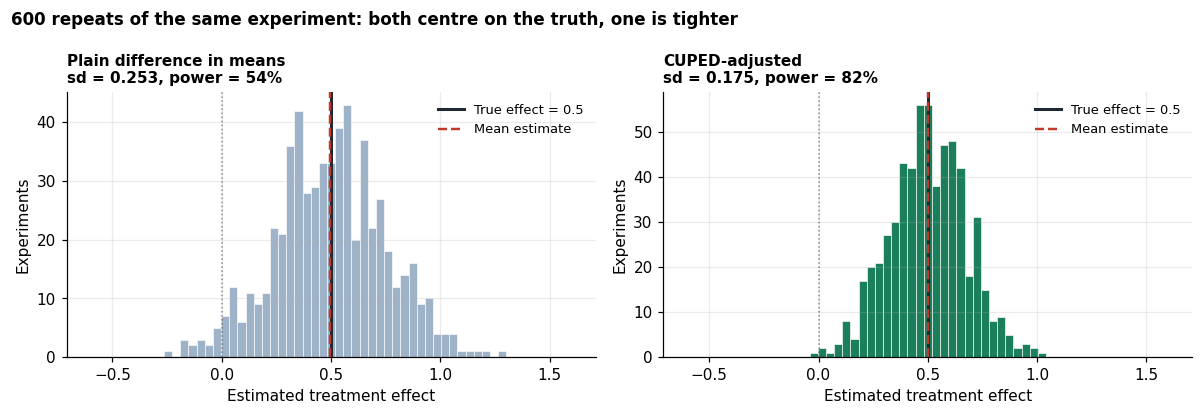

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

bins = np.linspace(-0.6, 1.6, 60)
for ax, (name, res, colour) in zip(
    axes,
    [("Plain difference in means", effect_plain, MUTED), ("CUPED-adjusted", effect_cuped, GOOD)],
):
    ax.hist(res["estimates"], bins=bins, color=colour, edgecolor="white", linewidth=0.4)
    ax.axvline(TRUE_EFFECT, color=INK, lw=2, label=f"True effect = {TRUE_EFFECT}")
    ax.axvline(res["mean_estimate"], color=WARN, lw=1.6, ls="--", label="Mean estimate")
    ax.axvline(0, color=INK, lw=1, ls=":", alpha=0.5)
    ax.set_title(
        f"{name}\nsd = {res['sd_estimate']:.3f}, power = {res['rejection_rate']:.0%}",
        loc="left", fontweight="bold", fontsize=10,
    )
    ax.set_xlabel("Estimated treatment effect")
    ax.set_ylabel("Experiments")
    ax.legend(frameon=False, fontsize=8.5)

fig.suptitle(
    f"{N_SIMS} repeats of the same experiment: both centre on the truth, one is tighter",
    fontsize=11, fontweight="bold", x=0.01, ha="left",
)
fig.tight_layout()
fig.savefig(FIGURES / "cuped.png", dpi=150, bbox_inches="tight")
plt.show()

Read the two histograms as the same experiment run 600 times. Both pile up on the true effect,
so neither method is biased — CUPED buys its precision honestly rather than by shading the
answer. The difference is width.

**The practical consequence is the power column.** With the plain estimator this experiment
detects its own real effect **54% of the time**: run it and you are near a coin flip on whether
you see what is genuinely there. With CUPED it is **82%**. Same users, same data, same true
effect — the difference is entirely in how much irrelevant variance the estimator was carrying.

That is the failure mode CUPED prevents: not a wrong answer, but a *shrug*. An underpowered
experiment returns "no significant difference", the team reads that as "no effect", and a real
improvement is discarded. Which is precisely the situation notebook 01's day-1 metric was in.

### The same thing expressed as users and calendar time

Variance reduction converts directly into sample size. If CUPED removes ~49% of the variance,
the same precision needs ~51% of the users.

In [6]:
plain_full = run_experiments(n_sims=200, effect=TRUE_EFFECT, method="plain", n=40_000)
cuped_half = run_experiments(n_sims=200, effect=TRUE_EFFECT, method="cuped", n=20_500)

print("Matching precision with fewer users:\n")
print(f"  plain, 40,000 users : mean CI width {plain_full['mean_ci_width']:.4f}")
print(f"  CUPED, 20,500 users : mean CI width {cuped_half['mean_ci_width']:.4f}")
print(f"\n  Same answer, {1 - 20_500 / 40_000:.0%} fewer users.")
print("\n  At a fixed traffic rate, a three-week experiment becomes a ten-day experiment -")
print("  or the same three weeks now resolve an effect half the size.")

Matching precision with fewer users:

  plain, 40,000 users : mean CI width 0.9505
  CUPED, 20,500 users : mean CI width 0.9481

  Same answer, 49% fewer users.

  At a fixed traffic rate, a three-week experiment becomes a ten-day experiment -
  or the same three weeks now resolve an effect half the size.


This is why CUPED is standard at anywhere running experiments at scale. Experimentation capacity
is bounded by traffic, and traffic is fixed. Halving the users per test doubles the number of
tests you can run in a quarter, without buying a single extra user.

## 5. The trap: a covariate measured during the experiment

Here is the shortcut. Cookie Cats has no pre-period data, but it does have `sum_gamerounds`,
which is numeric, strongly related to retention, and sitting right there in the dataframe. Using
it as the CUPED covariate takes one line and makes the intervals narrower. Plenty of published
analyses of this dataset do exactly that.

Below, `z` plays that role: measured during the experiment, correlated with `x` about as
strongly as `y` is, and — because the treatment changes user behaviour — **moved by the
treatment**. I switch on `leak=1.0` so that being in treatment raises `z`.

Nothing about this covariate looks wrong from inside the dataframe. The correlation is good and
the intervals do get tighter. Watch the estimate.

In [7]:
LEAK = 1.0
broken = run_experiments(effect=TRUE_EFFECT, method="cuped_post", leak=LEAK)

verdict = pd.DataFrame({
    "plain (no adjustment)": effect_plain,
    "CUPED on PRE-period x": effect_cuped,
    "'CUPED' on DURING-experiment z": broken,
}).T[["mean_estimate", "mean_ci_width", "coverage", "rejection_rate"]]
verdict.columns = ["mean estimate", "mean CI width", "CI coverage", "rejection rate"]

print(f"True effect = {TRUE_EFFECT}\n")
print(verdict.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\n  The true effect is {TRUE_EFFECT:+}. "
      f"The post-treatment adjustment estimates {broken['mean_estimate']:+.3f}.")
print(f"  Its 95% interval contains the truth {broken['coverage']:.1%} of the time.")

True effect = 0.5

                               mean estimate mean CI width CI coverage rejection rate
plain (no adjustment)                 0.4969        0.9503      0.9433         0.5400
CUPED on PRE-period x                 0.4998        0.6786      0.9500         0.8167
'CUPED' on DURING-experiment z       -0.2982        0.7873      0.0233         0.3150

  The true effect is +0.5. The post-treatment adjustment estimates -0.298.
  Its 95% interval contains the truth 2.3% of the time.


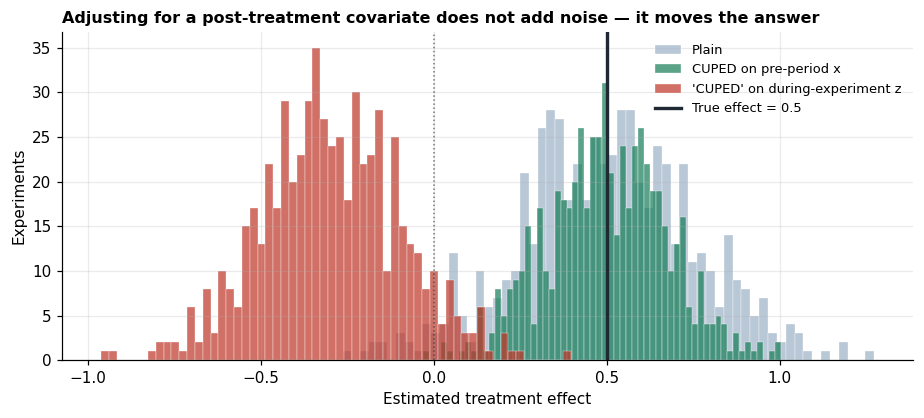

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 3.9))

series = [
    ("Plain", effect_plain["estimates"], MUTED),
    ("CUPED on pre-period x", effect_cuped["estimates"], GOOD),
    ("'CUPED' on during-experiment z", broken["estimates"], WARN),
]
for label, values, colour in series:
    ax.hist(values, bins=60, alpha=0.72, color=colour, label=label, edgecolor="white", linewidth=0.3)

ax.axvline(TRUE_EFFECT, color=INK, lw=2.2, label=f"True effect = {TRUE_EFFECT}")
ax.axvline(0, color=INK, lw=1, ls=":", alpha=0.6)
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("Experiments")
ax.set_title(
    "Adjusting for a post-treatment covariate does not add noise — it moves the answer",
    loc="left", fontweight="bold", fontsize=10.5,
)
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIGURES / "post_treatment_trap.png", dpi=150, bbox_inches="tight")
plt.show()

**The true effect is +0.5. The post-treatment adjustment reports −0.30.** The sign is wrong. Not
noisier, not less precise — pointed the other way, with a tighter interval than the plain
estimator and a 95% confidence interval that contains the truth **2% of the time**.

This is the worst possible failure mode, because every surface signal says the analysis improved.
The intervals narrowed. The correlation was strong. The code ran. And the recommendation it
produces is the opposite of the truth.

**Why it happens.** `θ(Z − Z̄)` is supposed to subtract variation the treatment did not cause. If
the treatment moves `Z`, then part of what gets subtracted *is the treatment effect*. You remove
the signal along with the noise, and if the leak is large enough relative to the effect, you
remove more than all of it and the estimate crosses zero. The formal name is **post-treatment
conditioning**; the shorter version is that you are adjusting away the thing you are trying to
measure.

**The test that keeps you safe** is not statistical, it is chronological: *was this variable
already determined at the moment of assignment?* If assignment could have changed it, it cannot
go on the right-hand side. That test would have caught `sum_gamerounds` in notebook 01 without
any of the arithmetic above.

It is the same error as filtering to `sum_gamerounds >= 30` in section 10 of notebook 01 —
selecting on a post-treatment variable there, adjusting for one here. Both break the guarantee
that randomisation gives you, and randomisation is the only reason any of this is causal.

## 6. What this means for the Cookie Cats analysis

Putting it together:

| | |
|---|---|
| Is the test calibrated? | Yes — 5.7% false positives under a true null, against a nominal 5% |
| Does it recover a known effect? | Yes — unbiased, 94% interval coverage |
| Would CUPED have helped? | Substantially. ~52% less variance, ~29% narrower intervals, power 54% → 82% |
| Can CUPED be applied to Cookie Cats? | **No.** There is no pre-assignment covariate in the data |
| What if I used `sum_gamerounds` anyway? | The estimate becomes biased, potentially sign-flipped, while *looking* more precise |

So the honest reporting for notebook 01 is: the day-7 result stands on the unadjusted estimate,
and the day-1 result stays inconclusive with a wider interval than it needed to have. If the game
had logged even one week of pre-install behaviour — which for new installs it cannot, but for an
experiment on existing players it would — the day-1 question might have been answerable.

**And that is the design lesson worth carrying into the next experiment**: whether you can use
variance reduction is decided when the logging is specified, not when the analysis is written. By
the time you have the data, it is too late to go back and measure the week before.